In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  # устанавливаем seaborn по умолчанию для отрисовки графиков

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cir = pd.read_csv('/content/drive/MyDrive/cirrhosis.csv', sep=',')
cir

#ID -уникальный идентификатор
#N_Days - количество дней между регистрацией и более ранним сроком смерти, трансплантации или проведения анализа в июле 1986 года
#Status - статус пациента: C (цензурировано), CL (цензурировано из-за лечения печени) или D (смерть)
#Drug - статус пациен Тип препарата: D-пеницилламин или плацебо
#Age - возраст (дни)
#Sex - M (male) or F (female)
#Ascites - наличие асцита N (нет) или Y (да)
#	Hepatomegaly - наличие гепатомегалии N (нет) или Y (да)
#	Spiders - наличие пауков: N (нет) или Y (да)
#Edema - 	наличие отёков N (отёков нет, диуретики для лечения отёков не применяются), S (отёки присутствуют, диуретики не применяются, или отёки прошли после приёма диуретиков) или Y (отёки сохраняются, несмотря на приём диуретиков)
#Bilirubin - сывороточный билирубин	мг / дл
#Cholesterol - 	сывороточный холестерин	мг / дл
#	Albumin - 	альбумин	г/дл
#Copper - 	медь в моче	мкг/день
#	Alk_Phos - 	щелочная фосфатаза	Ед /литр
#SGOT -
#	Tryglicerides - 	триглицериды
#Platelets - 	количество тромбоцитов в кубическом
#Prothrombin - 	протромбиновое время
#	Stage - гистологическая стадия заболевания (1, 2, 3 или 4)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [ ]:
cir.describe() #общая статистика

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [ ]:
cir.info() #типы полей, количество непустых записей и т.п.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [ ]:
cir.isnull().sum() #Пропущенные значения

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


In [ ]:
cir.drop(columns=['ID', 'Drug', 'Ascites', 'Hepatomegaly','Spiders'], inplace=True)
cir.isnull().sum() #удаляем столбцы, пустые значения которых не представляется возможным заменить

,0
N_Days,0
Status,0
Age,0
Sex,0
Edema,0
Bilirubin,0
Cholesterol,134
Albumin,0
Copper,108
Alk_Phos,106


In [ ]:
cir

,N_Days,Status,Age,Sex,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,D,21464,F,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,C,20617,F,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,D,25594,M,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,D,19994,F,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,CL,13918,F,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,681,D,24472,F,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,1103,C,14245,F,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,1055,C,20819,F,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,691,C,21185,F,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [ ]:
cir.Cholesterol.describe() #подробности поля

,Cholesterol
count,284.000000
mean,369.510563
std,231.944545
min,120.000000
25%,249.500000
50%,309.500000
75%,400.000000
max,1775.000000


In [ ]:
cir.Cholesterol = cir.Cholesterol.fillna(cir.Cholesterol.median())
cir.Cholesterol.describe()

,Cholesterol
count,418.000000
mean,350.272727
std,193.123893
min,120.000000
25%,273.000000
50%,309.500000
75%,347.750000
max,1775.000000


In [ ]:
cir.Copper.describe()

,Copper
count,310.000000
mean,97.648387
std,85.613920
min,4.000000
25%,41.250000
50%,73.000000
75%,123.000000
max,588.000000


In [ ]:
cir.Copper = cir.Copper.fillna(cir.Copper.median())
cir.Copper.describe()

,Copper
count,418.000000
mean,91.279904
std,74.485481
min,4.000000
25%,51.250000
50%,73.000000
75%,100.750000
max,588.000000


In [ ]:
cir.Alk_Phos.describe()

,Alk_Phos
count,312.000000
mean,1982.655769
std,2140.388824
min,289.000000
25%,871.500000
50%,1259.000000
75%,1980.000000
max,13862.400000


In [ ]:
cir.Alk_Phos = cir.Alk_Phos.fillna(cir.Alk_Phos.median())
cir.Alk_Phos.describe()

,Alk_Phos
count,418.000000
mean,1799.144976
std,1875.121982
min,289.000000
25%,1016.250000
50%,1259.000000
75%,1707.750000
max,13862.400000


In [ ]:
cir.SGOT.describe()

,SGOT
count,312.000000
mean,122.556346
std,56.699525
min,26.350000
25%,80.600000
50%,114.700000
75%,151.900000
max,457.250000


In [ ]:
cir.SGOT = cir.SGOT.fillna(cir.SGOT.median())
cir.SGOT.describe()

,SGOT
count,418.000000
mean,120.564067
std,49.085094
min,26.350000
25%,91.000000
50%,114.700000
75%,135.750000
max,457.250000


In [ ]:
cir.Tryglicerides.describe()

,Tryglicerides
count,282.000000
mean,124.702128
std,65.148639
min,33.000000
25%,84.250000
50%,108.000000
75%,151.000000
max,598.000000


In [ ]:
cir.Tryglicerides = cir.Tryglicerides.fillna(cir.Tryglicerides.median())
cir.Tryglicerides.describe()

,Tryglicerides
count,418.000000
mean,119.267943
std,54.050691
min,33.000000
25%,95.000000
50%,108.000000
75%,127.750000
max,598.000000


In [ ]:
cir.Platelets.describe()

,Platelets
count,407.000000
mean,257.024570
std,98.325585
min,62.000000
25%,188.500000
50%,251.000000
75%,318.000000
max,721.000000


In [ ]:
cir.Platelets = cir.Platelets.fillna(cir.Platelets.median())
cir.Platelets.describe()

,Platelets
count,418.000000
mean,256.866029
std,97.024861
min,62.000000
25%,190.000000
50%,251.000000
75%,315.500000
max,721.000000


In [ ]:
cir.Prothrombin.describe()

,Prothrombin
count,416.000000
mean,10.731731
std,1.022000
min,9.000000
25%,10.000000
50%,10.600000
75%,11.100000
max,18.000000


In [ ]:
cir.Prothrombin = cir.Prothrombin.fillna(cir.Prothrombin.median())
cir.Prothrombin.describe()

,Prothrombin
count,418.000000
mean,10.731100
std,1.019587
min,9.000000
25%,10.000000
50%,10.600000
75%,11.100000
max,18.000000


In [ ]:
cir.Stage.describe()

,Stage
count,412.000000
mean,3.024272
std,0.882042
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,4.000000


In [ ]:
cir.Stage = cir.Stage.fillna(cir.Stage.median())
cir.Stage.describe()

,Stage
count,418.000000
mean,3.023923
std,0.875678
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,4.000000


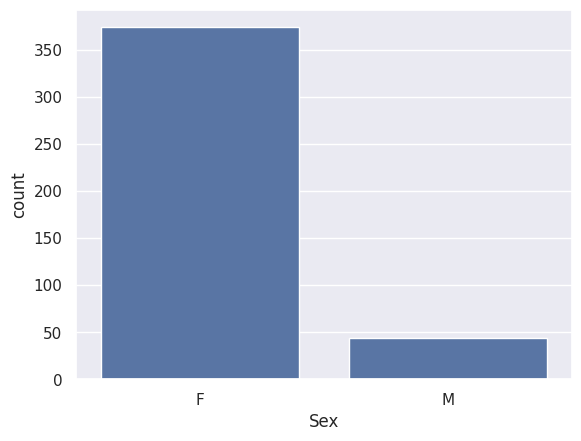

In [ ]:
sns.countplot(x=cir["Sex"]); #женщины болеют чаще

(array([ 8., 37., 49., 64., 75., 77., 49., 39., 15.,  5.]),
 array([ 9598. , 11503.2, 13408.4, 15313.6, 17218.8, 19124. , 21029.2,
        22934.4, 24839.6, 26744.8, 28650. ]),
 <BarContainer object of 10 artists>)

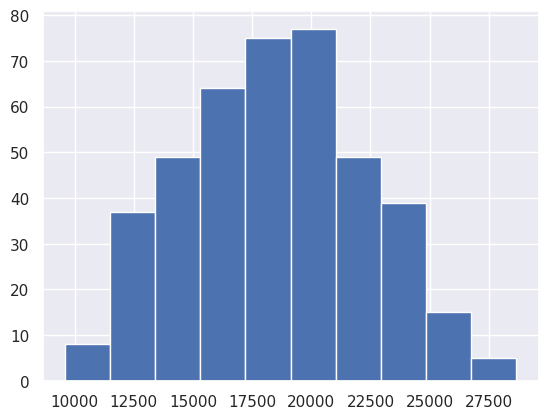

In [ ]:
plt.hist(cir['Age'])

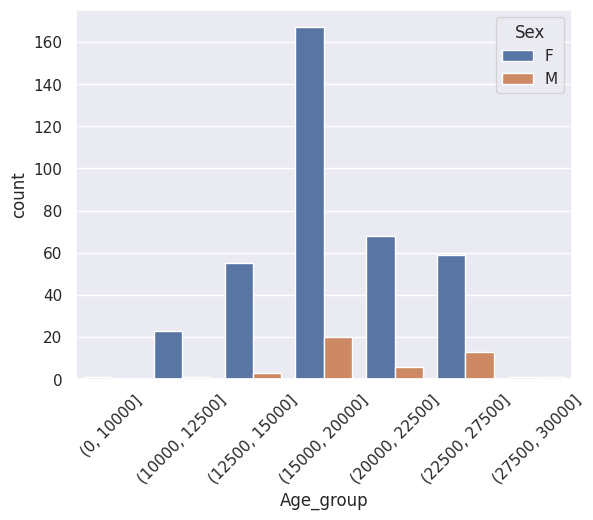

In [ ]:
cir["Age_group"] = pd.cut(x=cir['Age'], bins=[0, 10000, 12500, 15000, 20000, 22500, 27500, 30000])
plt.xticks(rotation=45)
sns.countplot(data=cir, hue='Sex', x='Age_group');

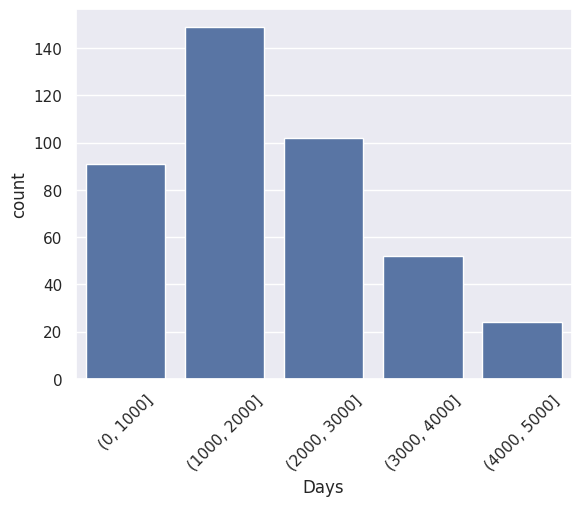

In [ ]:
cir["Days"] = pd.cut(x=cir['N_Days'], bins=[0, 1000, 2000, 3000, 4000, 5000])
plt.xticks(rotation=45)
sns.countplot(x=cir["Days"]);

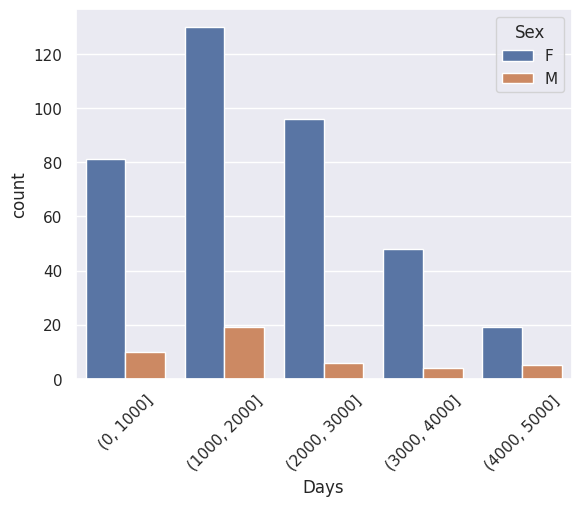

In [ ]:
cir["Days"] = pd.cut(x=cir['N_Days'], bins=[0, 1000, 2000, 3000, 4000, 5000])
plt.xticks(rotation=45)
sns.countplot(data=cir, hue='Sex', x='Days');

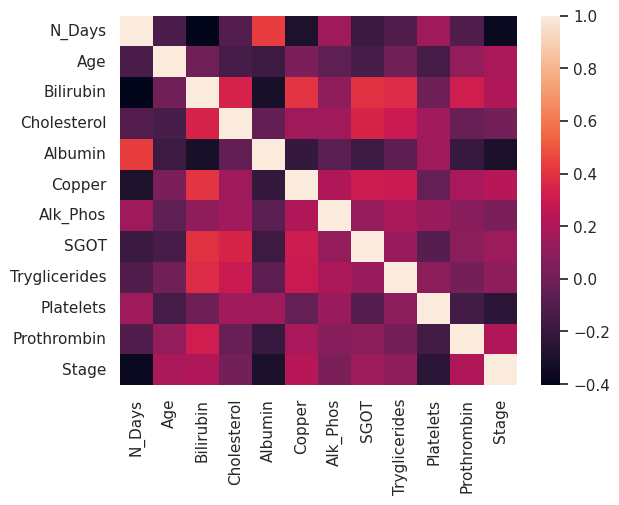

In [ ]:
sns.heatmap(cir.corr(numeric_only = True));

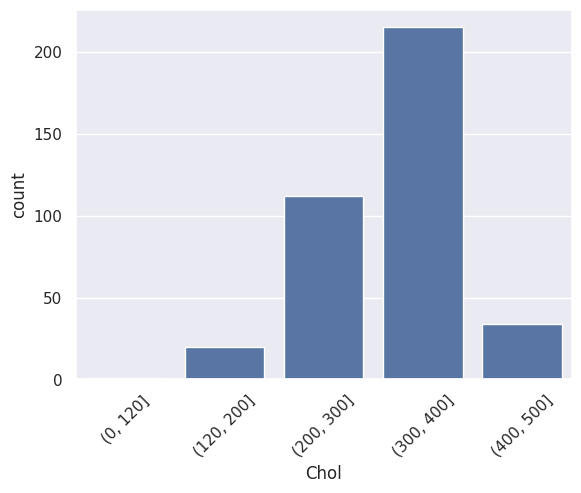

In [ ]:
cir["Chol"] = pd.cut(x=cir['Cholesterol'], bins=[0, 120, 200, 300, 400, 500])
plt.xticks(rotation=45)
sns.countplot(x=cir["Chol"]);

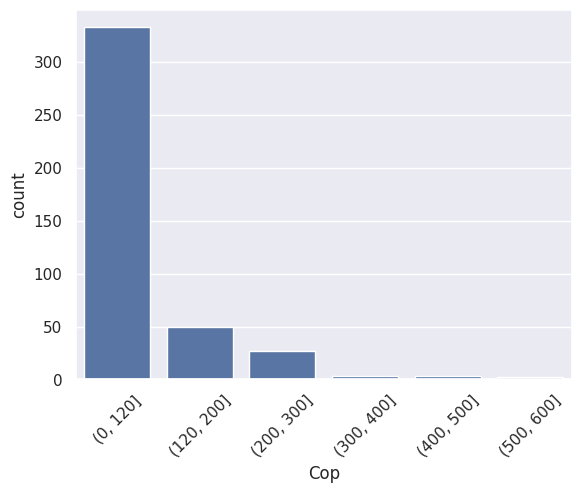

In [ ]:
cir["Cop"] = pd.cut(x=cir['Copper'], bins=[0, 120, 200, 300, 400, 500, 600])
plt.xticks(rotation=45)
sns.countplot(x=cir["Cop"]);

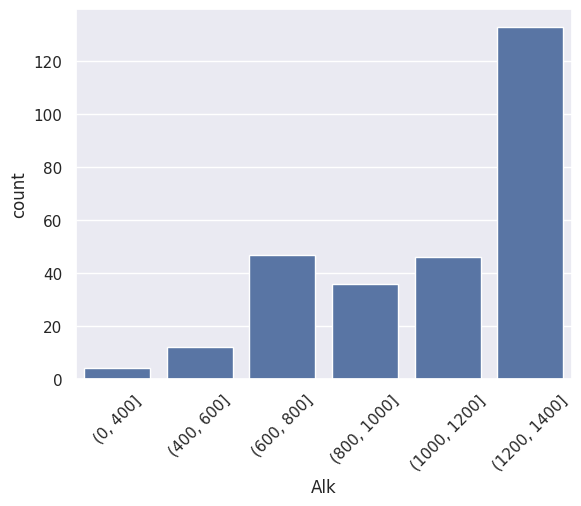

In [ ]:
cir["Alk"] = pd.cut(x=cir['Alk_Phos'], bins=[0, 400, 600, 800, 1000, 1200, 1400])
plt.xticks(rotation=45)
sns.countplot(x=cir["Alk"]);

(array([ 63., 183., 116.,  35.,  14.,   4.,   1.,   0.,   0.,   2.]),
 array([ 9. ,  9.9, 10.8, 11.7, 12.6, 13.5, 14.4, 15.3, 16.2, 17.1, 18. ]),
 <BarContainer object of 10 artists>)

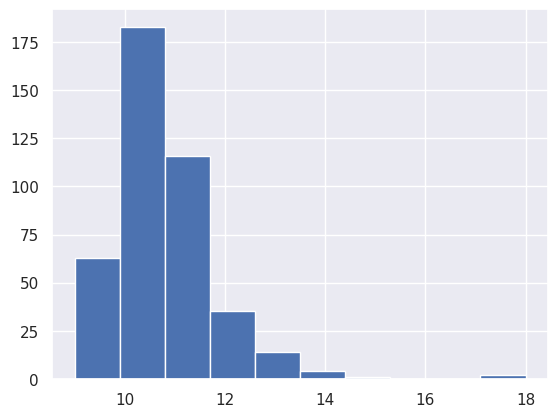

In [ ]:
plt.hist(cir['Prothrombin'])

(array([ 21.,   0.,   0.,  92.,   0.,   0., 161.,   0.,   0., 144.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

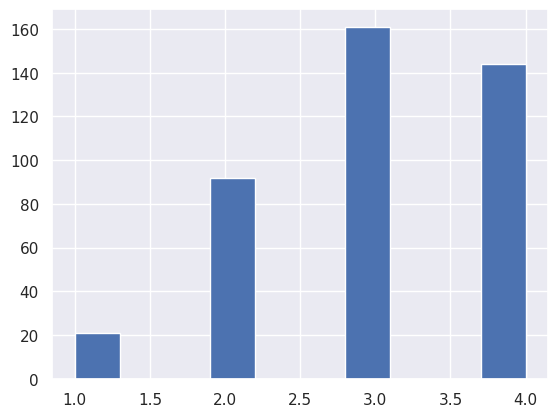

In [ ]:
plt.hist(cir['Stage'])

In [ ]:
# ДЗ2

In [ ]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
cir

,N_Days,Status,Age,Sex,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Age_group,Days,Chol,Cop,Alk
0,400,D,21464,F,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0,"(20000, 22500]","(0, 1000]","(200, 300]","(120, 200]",NaN
1,4500,C,20617,F,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0,"(20000, 22500]","(4000, 5000]","(300, 400]","(0, 120]",NaN
2,1012,D,25594,M,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0,"(22500, 27500]","(1000, 2000]","(120, 200]","(200, 300]","(400.0, 600.0]"
3,1925,D,19994,F,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0,"(15000, 20000]","(1000, 2000]","(200, 300]","(0, 120]",NaN
4,1504,CL,13918,F,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0,"(12500, 15000]","(1000, 2000]","(200, 300]","(120, 200]","(600.0, 800.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,681,D,24472,F,N,1.2,309.5,2.96,73.0,1259.0,114.70,108.0,174.0,10.9,3.0,"(22500, 27500]","(0, 1000]","(300, 400]","(0, 120]","(1200.0, 1400.0]"
414,1103,C,14245,F,N,0.9,309.5,3.83,73.0,1259.0,114.70,108.0,180.0,11.2,4.0,"(12500, 15000]","(1000, 2000]","(300, 400]","(0, 120]","(1200.0, 1400.0]"
415,1055,C,20819,F,N,1.6,309.5,3.42,73.0,1259.0,114.70,108.0,143.0,9.9,3.0,"(20000, 22500]","(1000, 2000]","(300, 400]","(0, 120]","(1200.0, 1400.0]"
416,691,C,21185,F,N,0.8,309.5,3.75,73.0,1259.0,114.70,108.0,269.0,10.4,3.0,"(20000, 22500]","(0, 1000]","(300, 400]","(0, 120]","(1200.0, 1400.0]"


In [ ]:
cir['Stage'].unique()

array([4., 3., 2., 1.])

In [ ]:
# Теперь проверим количество строк, которое принадлежит каждому классу:

cir['Stage'].value_counts()

,count
Stage,
3.0,161
4.0,144
2.0,92
1.0,21


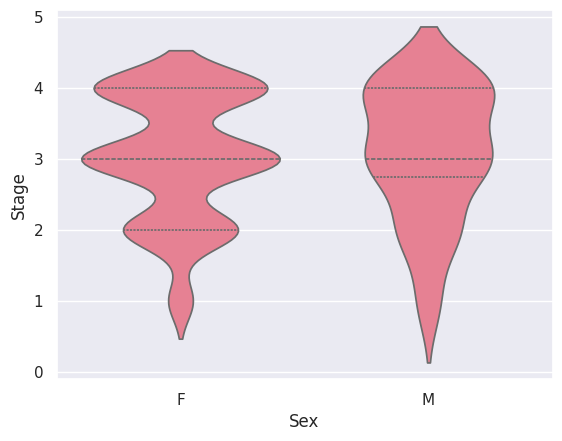

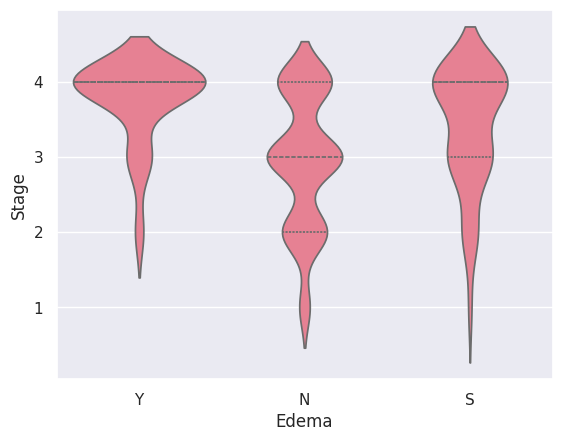

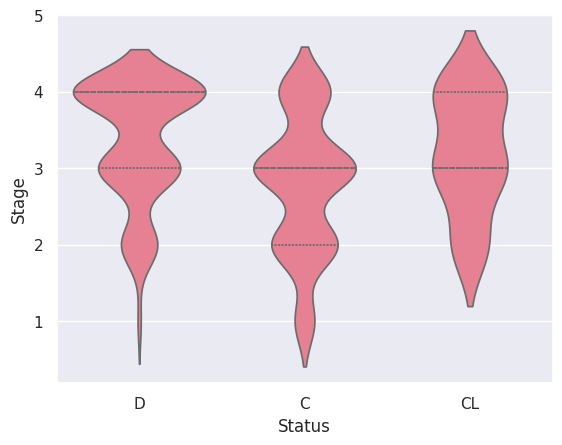

In [ ]:
# Скрипичный график.
# Используется для проверки сравнения распределения переменных:


sns.violinplot(y='Stage', x='Sex', data=cir, inner='quartile')
plt.show()
sns.violinplot(y='Stage', x='Edema', data=cir, inner='quartile')
plt.show()
sns.violinplot(y='Stage', x='Status', data=cir, inner='quartile')
plt.show()

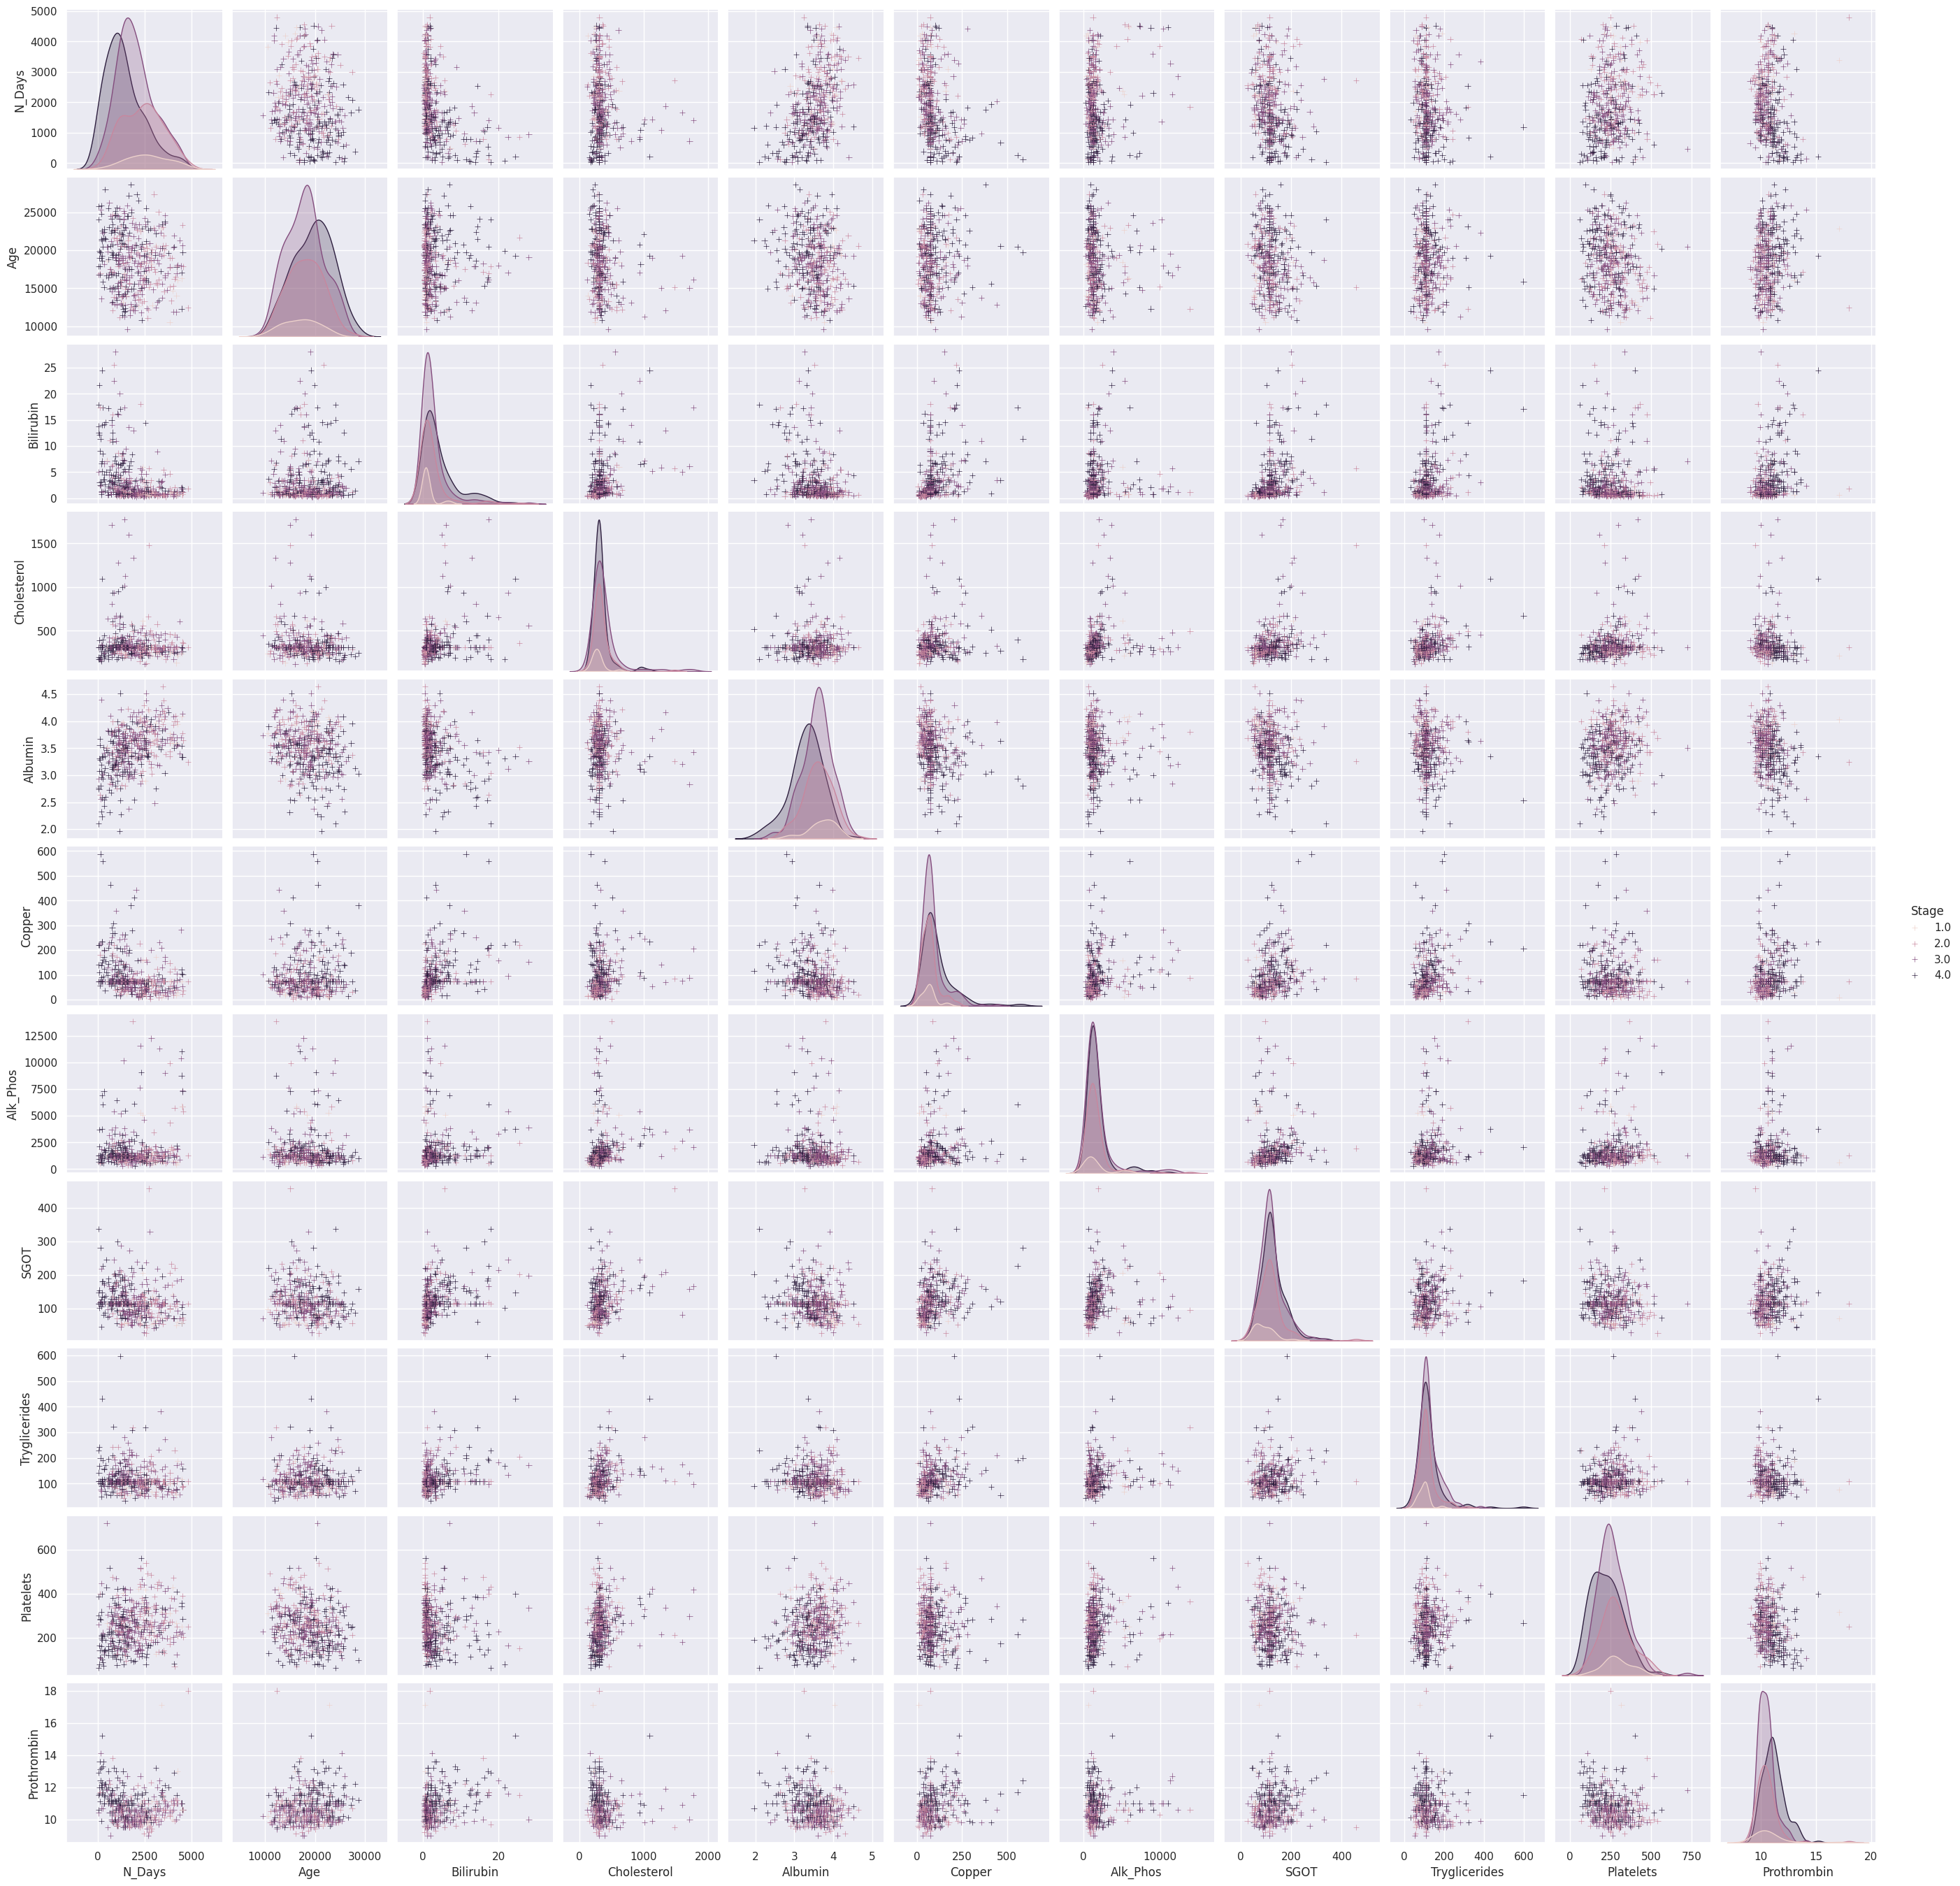

In [ ]:
# Парный график
#Построение нескольких попарных двумерных распределений в наборе данных с помощью pairplot:

sns.pairplot(cir, hue='Stage', markers='+')
plt.show()

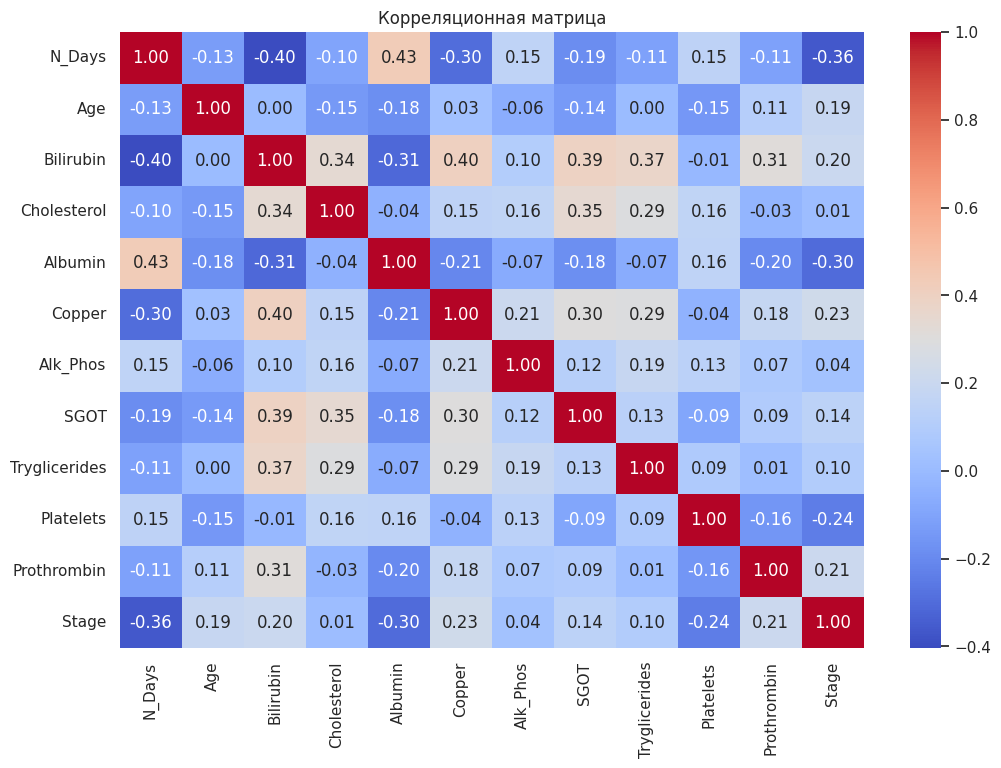

In [119]:
df_cleaned = cir.select_dtypes(include=[np.number]).dropna()
# Построение матрицы корреляции
correlation_matrix = df_cleaned.corr()

# Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

In [125]:
# 4. Выбор столбцов, которые максимально коррелируют со столбцом "Stage"
target_column = 'Stage'
correlation_with_target = correlation_matrix[target_column].drop(target_column)
high_correlation_features = correlation_with_target[correlation_with_target.abs() > 0.3].index.tolist()

print("Столбцы с высокой корреляцией:", high_correlation_features)

Столбцы с высокой корреляцией: ['N_Days', 'Albumin']


In [126]:
X = cir.drop(['Stage'], axis=1)
y = cir_cleaned['Stage']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (418, 19) | y shape: (418,) 


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.20, random_state=15, stratify=y_mapped)

stats.ttest_ind (a=y_train, b=y_test)

ValueError: Input y contains NaN.

In [ ]:
# создаем лист для тех моделей, которые будем изучать
models = []
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVC', SVC(gamma='auto')))

# оцениваем их метрики
results = []
model_names = []
for name, model in models:
  kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
  cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
  results.append(cv_results)
  model_names.append(name)
  print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

In [ ]:
sk_lda = LinearDiscriminantAnalysis(solver='eigen')
sk_lda.fit(X_train, y_train)
sk_lda_pred_res = sk_lda.predict(X_test)
sk_transformed = sk_lda.transform(X_train)
sk_lda_accuracy = accuracy_score(y_test, sk_lda_pred_res)

print(f'sk LDA accuracy: {sk_lda_accuracy}')
print(f'sk LDA prediction: {sk_lda_pred_res}')
print('sk transformed features', sk_transformed[:5].T, sep='\n')

In [ ]:
from mlxtend.plotting import plot_decision_regions

# Создадим целевой вектор y_2d
# Преобразуем классы к классам 0, 1, 2 соответственно
#y_s = y_train.map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
y_s = y_train
X_2d= X_train[['sepal-lenght',	'sepal-width']].values

y_2d = y_s.values


sk_lda1 = LinearDiscriminantAnalysis(solver='eigen')
sk_lda1.fit(X_2d, y_2d)

plt.title('LDA surface with original features')
plot_decision_regions(
    	X=X_2d,
    	y=y_2d,
    	clf=sk_lda1)

In [ ]:
df = dataset["class"].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

Xs = dataset[['sepal-lenght',	'sepal-width']]
ys = df.values

sk_lda2 = LinearDiscriminantAnalysis(solver='eigen')
X1_lda = sk_lda2.fit(X, ys).transform(X)

Xs = X1_lda

X1_lda_train, X1_lda_test, y1_train, y1_test = train_test_split(X1_lda, ys, random_state=0)

sk_lda2.fit(X1_lda_train, y1_train)

plt.title('LDA surface with transformed features')
plot_decision_regions(X=X1_lda, y=ys, clf=sk_lda2)

In [ ]:
predicted = sk_lda2.predict(X1_lda_test)


In [ ]:
from sklearn import model_selection, preprocessing, feature_selection, ensemble, linear_model, metrics, decomposition

## Accuray e AUC
'''
Теперь смотрим метрики.
НА ТЕСТОВОМ ДАТАСЕТЕ
'''
accuracy = metrics.accuracy_score(y1_test, predicted)#Оценим точность классификации.

'''
Получим результат
'''

## Precision e Recall
recall = metrics.recall_score(y1_test, predicted, average="weighted")
precision = metrics.precision_score(y1_test, predicted, average="weighted")
print("Recall (all 1s predicted right):", round(recall,2))
print("Precision (confidence when predicting a 1):", round(precision,2))
print("Detail:")
print(metrics.classification_report(y1_test, predicted, target_names=[str(i) for i in np.unique(y_test)]))